# Анализ результатов `skin_screener`

Читает `skin_homog/DATA/_summary.csv` после прогона раннера.

- **pred_cv** — коэффициент вариации предиктов по листингам: $\sigma/\mu$ (безразмерный, уже сопоставим между скинами).
- **factor_cv** — то же для отношения `predicted / base` (при наличии base совпадает по смыслу с разбросом относительно базы).
- **Относительный диапазон предиктов** — $(p_{\max}-p_{\min})/\mu$ или к `base_price`, чтобы ширина «мин–макс» была сравнима между дешёвыми и дорогими скинами.

Запускайте ячейки по порядку.

In [15]:
from pathlib import Path

# Path to _summary.csv; None = auto-detect skin_homog/DATA near this notebook
SUMMARY_CSV: Path | None = None

MIN_LISTINGS = 3  # optional: drop skins with too few listings

SHOW_TOP_N = 18

# If True: load data_skins_big, but keep only items from lists/skins_normal_filtered2.py
# If False: keep all items that exist in data_skins_big
USE_ONLY_SKINS_NORMAL_FILTERED2 = True
SKINS_NORMAL_FILTERED2_PY: Path | None = None


In [16]:
import importlib.util

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError("matplotlib is required: pip install matplotlib") from e

DATA = "data_skins_big"


def _find_skin_homog() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "skin_homog" / DATA / "_summary.csv").is_file():
            return p / "skin_homog"
        if (p / DATA / "_summary.csv").is_file():
            return p
        p = p.parent
    raise FileNotFoundError("Could not find DATA/_summary.csv ? set SUMMARY_CSV manually.")


def _resolve_filtered_items_py(skin_homog_root: Path) -> Path:
    if SKINS_NORMAL_FILTERED2_PY is not None:
        return Path(SKINS_NORMAL_FILTERED2_PY).resolve()

    repo_root = skin_homog_root.parent if skin_homog_root.name == "skin_homog" else skin_homog_root
    path = repo_root / "lists" / "skins_normal_filtered2.py"
    if path.is_file():
        return path.resolve()
    raise FileNotFoundError(f"Could not find skins_normal_filtered2.py: {path}")


def _load_items_from_py(path: Path) -> list[str]:
    spec = importlib.util.spec_from_file_location("_skins_normal_filtered2", path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load item list from {path}")
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    items = getattr(mod, "ITEMS", None)
    if not isinstance(items, list):
        raise ValueError(f"No ITEMS list found in {path}")
    return [str(x) for x in items]


if SUMMARY_CSV is None:
    sh = _find_skin_homog()
    summary_path = sh / DATA / "_summary.csv"
else:
    summary_path = Path(SUMMARY_CSV).resolve()
    sh = summary_path.parent.parent if summary_path.parent.name == DATA else summary_path.parent

if not summary_path.is_file():
    raise FileNotFoundError(summary_path)

df = pd.read_csv(summary_path)
print("File:", summary_path)
print("Rows before item filter:", len(df), "| columns:", len(df.columns))

filtered_items = None
if USE_ONLY_SKINS_NORMAL_FILTERED2:
    items_py = _resolve_filtered_items_py(sh)
    filtered_items = set(_load_items_from_py(items_py))
    before = len(df)
    df = df[df["item"].astype(str).isin(filtered_items)].copy()
    print("Item filter enabled:", items_py)
    print(f"Rows after item filter: {len(df)} / {before}")
else:
    print("Item filter disabled: keeping all items from data_skins_big")

df.head(3)


File: C:\Roman\skins_roundtrip_v1\skin_homog\data_skins_big\_summary.csv
Rows before item filter: 956 | columns: 16
Item filter enabled: C:\Roman\skins_roundtrip_v1\lists\skins_normal_filtered2.py
Rows after item filter: 261 / 956


,item,base_price,reference_currency,float_qty,n_listings,ask_min,ask_median,ask_max,pred_mean,pred_std,pred_cv,pred_min,pred_max,factor_mean,factor_std,factor_cv
0,Desert Eagle | Calligraffiti (Factory New),15.26,NaN,279,130,16.13,20.685,64.16,19.0860,2.5777,0.1351,15.26,24.08,1.2507,0.1689,0.1351
4,SSG 08 | Ghost Crusader (Factory New),26.61,NaN,253,59,28.28,40.970,150.00,30.2875,4.1599,0.1373,25.63,39.81,1.1382,0.1563,0.1373
12,AK-47 | Head Shot (Field-Tested),37.22,NaN,1393,400,36.75,46.855,353.01,42.7844,6.3167,0.1476,36.68,56.75,1.1495,0.1697,0.1476


In [17]:
# Производные метрики (относительный диапазон предиктов)
pm = df["pred_mean"].astype(float)
pb = df["base_price"].astype(float)
pmin, pmax = df["pred_min"].astype(float), df["pred_max"].astype(float)

df["pred_span_usd"] = pmax - pmin
df["pred_range_over_mean"] = np.where(pm > 0, (pmax - pmin) / pm, np.nan)
df["pred_range_over_base"] = np.where(pb > 0, (pmax - pmin) / pb, np.nan)

# Насколько min-max шире «типичного» разброса std: ratio ≈ range / (2*std) для нормального распределения ~1.3
ps = df["pred_std"].replace(0, np.nan).astype(float)
df["range_over_2std"] = np.where(ps > 0, (pmax - pmin) / (2 * ps), np.nan)

ok = df["n_listings"] >= MIN_LISTINGS
d = df.loc[ok].copy()
print(f"После фильтра n_listings >= {MIN_LISTINGS}: {len(d)} строк")

for col in ["pred_cv", "factor_cv", "pred_range_over_mean", "pred_range_over_base"]:
    if col in d.columns:
        s = pd.to_numeric(d[col], errors="coerce")
        print(f"\n{col} — квантили:")
        print(s.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(4).to_string())

После фильтра n_listings >= 3: 261 строк

pred_cv — квантили:
0.05    0.0124
0.25    0.0437
0.50    0.0832
0.75    0.1411
0.95    0.2354

factor_cv — квантили:
0.05    0.0124
0.25    0.0437
0.50    0.0832
0.75    0.1411
0.95    0.2354

pred_range_over_mean — квантили:
0.05    0.0599
0.25    0.2272
0.50    0.3955
0.75    0.6903
0.95    2.6132

pred_range_over_base — квантили:
0.05    0.0602
0.25    0.2283
0.50    0.4175
0.75    0.7754
0.95    2.7950


In [18]:
# Умный текстовый отчёт: экстремумы и согласованность CV vs range
sub = d.dropna(subset=["pred_cv", "pred_mean"]).copy()

print("=== Самые однородные по pred_cv (низкий разброс предиктов) ===")
hom = sub.nsmallest(SHOW_TOP_N, "pred_cv")[
    [
        "item",
        "n_listings",
        "base_price",
        "pred_mean",
        "pred_cv",
        "pred_range_over_mean",
        "pred_min",
        "pred_max",
    ]
]
print(hom.to_string(index=False))

print("\n=== Самые гетерогенные по pred_cv ===")
het = sub.nlargest(SHOW_TOP_N, "pred_cv")[
    [
        "item",
        "n_listings",
        "base_price",
        "pred_mean",
        "pred_cv",
        "pred_range_over_mean",
        "pred_min",
        "pred_max",
    ]
]
print(het.to_string(index=False))

a = sub["pred_cv"]
b = sub["pred_range_over_mean"]
mask = a.notna() & b.notna()
if mask.sum() > 2:
    corr = a[mask].corr(b[mask])
    print(f"\nКорреляция pred_cv  vs  (pred_max-pred_min)/pred_mean: {corr:.3f}")

if sub["factor_cv"].notna().any():
    fc = sub["factor_cv"]
    pc = sub["pred_cv"]
    m = fc.notna() & pc.notna()
    if m.sum() > 2:
        print(f"Корреляция pred_cv vs factor_cv: {pc[m].corr(fc[m]):.3f} (ожидаемо ≈1 при стабильном base)")

=== Самые однородные по pred_cv (низкий разброс предиктов) ===
                                       item  n_listings  base_price  pred_mean  pred_cv  pred_range_over_mean  pred_min  pred_max
               FAMAS | Bad Trip (Well-Worn)          47       46.37    46.4302   0.0028              0.012923     46.17     46.77
              AWP | Hyper Beast (Well-Worn)          65       34.65    34.1169   0.0036              0.015242     33.84     34.36
Galil AR | Chromatic Aberration (Well-Worn)          78        3.66     3.6055   0.0041              0.030509      3.58      3.69
               AWP | POP AWP (Field-Tested)         132        9.51     9.6533   0.0068              0.032113      9.55      9.86
            USP-S | Printstream (Well-Worn)          20       38.80    37.8890   0.0081              0.029824     37.49     38.62
               MP9 | Food Chain (Well-Worn)          66        3.63     3.5529   0.0082              0.053477      3.52      3.71
              AK-47 | Night

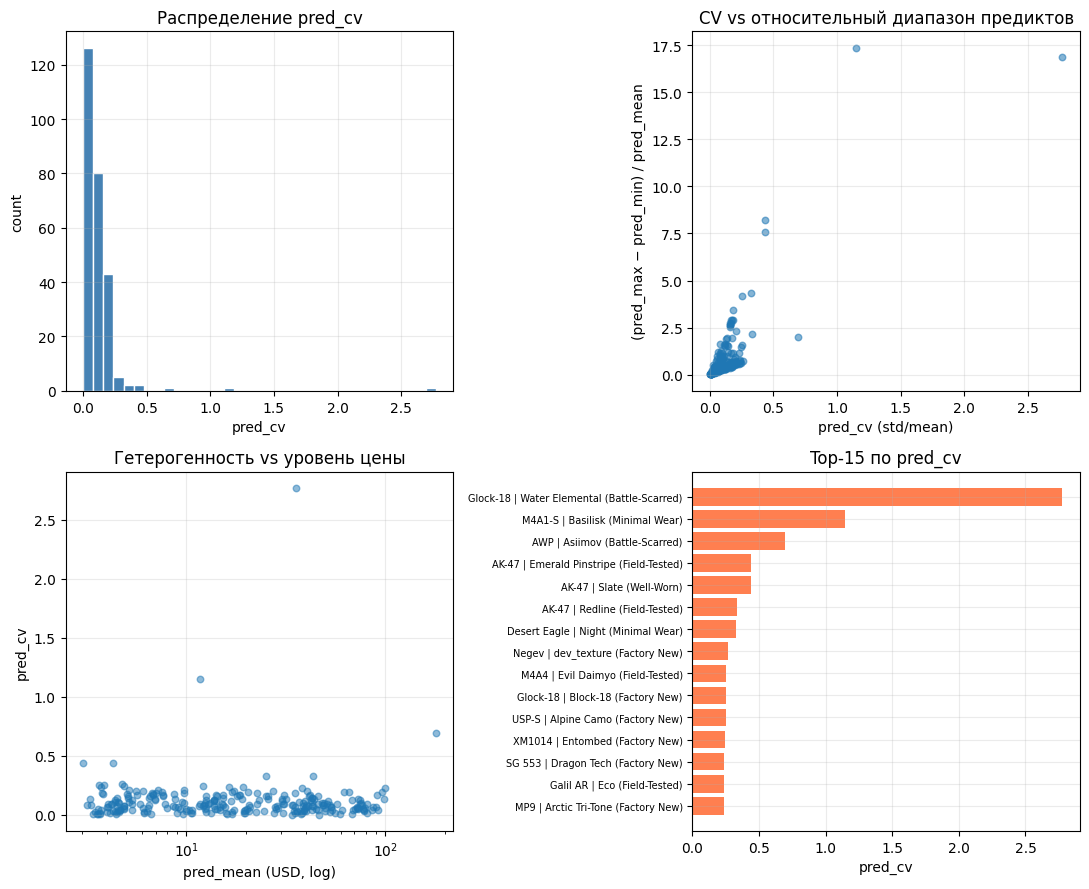

In [19]:
# Графики
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax = axes[0, 0]
x = d["pred_cv"].dropna()
ax.hist(x, bins=min(35, max(10, len(x) // 3)), color="steelblue", edgecolor="white")
ax.set_xlabel("pred_cv")
ax.set_ylabel("count")
ax.set_title("Распределение pred_cv")

ax = axes[0, 1]
s2 = d.dropna(subset=["pred_cv", "pred_range_over_mean"])
ax.scatter(s2["pred_cv"], s2["pred_range_over_mean"], alpha=0.55, s=22)
ax.set_xlabel("pred_cv (std/mean)")
ax.set_ylabel("(pred_max − pred_min) / pred_mean")
ax.set_title("CV vs относительный диапазон предиктов")

ax = axes[1, 0]
s3 = d.dropna(subset=["pred_mean", "pred_cv"])
ax.scatter(s3["pred_mean"], s3["pred_cv"], alpha=0.5, s=22)
ax.set_xscale("log")
ax.set_xlabel("pred_mean (USD, log)")
ax.set_ylabel("pred_cv")
ax.set_title("Гетерогенность vs уровень цены")

ax = axes[1, 1]
top = d.dropna(subset=["pred_cv"]).nlargest(15, "pred_cv")[["item", "pred_cv"]].iloc[::-1]
ax.barh(range(len(top)), top["pred_cv"], color="coral")
ax.set_yticks(range(len(top)))
short = top["item"].apply(lambda s: (str(s)[:52] + "…") if len(str(s)) > 52 else str(s))
ax.set_yticklabels(short, fontsize=7)
ax.set_xlabel("pred_cv")
ax.set_title("Top-15 по pred_cv")

plt.tight_layout()
plt.show()

**Интерпретация:** низкий `pred_cv` — предикты CSFloat по твоей выборке листингов почти не гуляют (скин «однородный» по оценке модели). Высокий `pred_cv` — сильный разброс (наклейки, редкие флоаты, выбросы в ask и т.д.). Относительный диапазон `(max−min)/mean` дополняет CV: он чувствителен к хвостам, CV — к типичному разбросу вокруг среднего.

In [20]:
# Однородные скины → фрагмент для .py списка (как в skin_cands)
import json

PRED_CV_THRESHOLD = 0.05  # строго меньше; поменяй при необходимости

try:
    _src = d
except NameError:
    _src = df

low = _src[_src["pred_cv"].notna() & (_src["pred_cv"] < PRED_CV_THRESHOLD) & (_src["pred_range_over_mean"] < 0.2)].sort_values(
    ["pred_cv", "item"]
)

print(f"# count = {len(low)}  (pred_cv < {PRED_CV_THRESHOLD})\n")
print("ITEMS = [")
for s in low["item"].astype(str):
    print(f"    {json.dumps(s)},")
print("]")

# count = 53  (pred_cv < 0.05)

ITEMS = [
    "FAMAS | Bad Trip (Well-Worn)",
    "AWP | Hyper Beast (Well-Worn)",
    "Galil AR | Chromatic Aberration (Well-Worn)",
    "AWP | POP AWP (Field-Tested)",
    "USP-S | Printstream (Well-Worn)",
    "MP9 | Food Chain (Well-Worn)",
    "AK-47 | Nightwish (Well-Worn)",
    "P2000 | Wicked Sick (Well-Worn)",
    "M4A1-S | Flashback (Well-Worn)",
    "AK-47 | Frontside Misty (Well-Worn)",
    "UMP-45 | Neo-Noir (Well-Worn)",
    "USP-S | Kill Confirmed (Well-Worn)",
    "AWP | Ice Coaled (Well-Worn)",
    "SSG 08 | Parallax (Minimal Wear)",
    "M4A1-S | Player Two (Battle-Scarred)",
    "M4A1-S | Glitched Paint (Well-Worn)",
    "USP-S | Purple DDPAT (Field-Tested)",
    "FAMAS | Pulse (Field-Tested)",
    "USP-S | Royal Blue (Field-Tested)",
    "Glock-18 | AXIA (Battle-Scarred)",
    "Glock-18 | Water Elemental (Well-Worn)",
    "M4A1-S | Flashback (Minimal Wear)",
    "AWP | Chrome Cannon (Well-Worn)",
    "Desert Eagle | Conspiracy (Field-

In [21]:
# Heterogeneous skins -> fragment for a .py list file (same style as skin_cands)
import json

PRED_CV_THRESHOLD_HIGH = 0.075  # strictly greater than this
SAVE_HIGH_TO_SCREENING_STEAM_LISTING = True
SCREENING_STEAM_LISTING_PY: Path | None = None

try:
    _src = d
except NameError:
    _src = df

high = _src[
    _src["pred_cv"].notna()
    & (_src["pred_cv"] > PRED_CV_THRESHOLD_HIGH)
    & (_src["pred_range_over_mean"] > 0.3)
].sort_values(["pred_cv", "item"])

print(f"# count = {len(high)}  (pred_cv > {PRED_CV_THRESHOLD_HIGH})\n")
print("ITEMS = [")
for s in high["item"].astype(str):
    print(f"    {json.dumps(s, ensure_ascii=False)},")
print("]")

if SAVE_HIGH_TO_SCREENING_STEAM_LISTING:
    repo_root = sh.parent if sh.name == "skin_homog" else sh
    out_path = (
        Path(SCREENING_STEAM_LISTING_PY).resolve()
        if SCREENING_STEAM_LISTING_PY is not None
        else (repo_root / "lists" / "screening_steam_listing.py").resolve()
    )
    lines = [
        f"# count = {len(high)}  (pred_cv > {PRED_CV_THRESHOLD_HIGH})",
        "",
        "ITEMS = [",
    ]
    for s in high["item"].astype(str):
        lines.append(f"    {json.dumps(s, ensure_ascii=False)},")
    lines.append("]")
    out_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    print(f"\nSaved to: {out_path}")


# count = 135  (pred_cv > 0.075)

ITEMS = [
    "MP9 | Airlock (Field-Tested)",
    "Galil AR | Rainbow Spoon (Minimal Wear)",
    "M4A1-S | Guardian (Field-Tested)",
    "AK-47 | Nouveau Rouge (Minimal Wear)",
    "Desert Eagle | Printstream (Field-Tested)",
    "AK-47 | Neon Rider (Field-Tested)",
    "Desert Eagle | Midnight Storm (Minimal Wear)",
    "AK-47 | Elite Build (Minimal Wear)",
    "Five-SeveN | Case Hardened (Battle-Scarred)",
    "Desert Eagle | Printstream (Minimal Wear)",
    "USP-S | Black Lotus (Minimal Wear)",
    "Glock-18 | Steel Disruption (Factory New)",
    "USP-S | The Traitor (Battle-Scarred)",
    "Glock-18 | Water Elemental (Minimal Wear)",
    "Tec-9 | Fuel Injector (Field-Tested)",
    "AWP | Exoskeleton (Field-Tested)",
    "USP-S | Jawbreaker (Minimal Wear)",
    "Glock-18 | Gold Toof (Minimal Wear)",
    "AWP | Sun in Leo (Field-Tested)",
    "AK-47 | Asiimov (Field-Tested)",
    "M4A4 | Tooth Fairy (Field-Tested)",
    "Desert Eagle | Kumicho Dragon 